<a href="https://colab.research.google.com/github/gunjancs23149/Machine-Learing-Project/blob/main/ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **1. Import Libraries**

Let's start by importing all the necessary libraries for data manipulation, visualization, and building our neural network model.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Set display options for pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)


### **2. Load Dataset**

Now, let's load your provided CSV file into a pandas DataFrame and display the first few rows to get an initial look at the data.

In [ ]:
file_path = '/content/drive/MyDrive/TG-NPDCL_consumption_detail_commercial_JANUARY-2025.csv'
try:
    df = pd.read_csv(file_path)
    print("Dataset loaded successfully. Displaying the first 5 rows:")
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please ensure the path is correct.")
except Exception as e:
    print(f"An error occurred while loading the dataset: {e}")


Dataset loaded successfully. Displaying the first 5 rows:


,Circle,Division,SubDivision,Section,Area,CatCode,CatDesc,TotServices,BilledServices,Units,Load
0,WARANGAL,RURAL WARANGAL,WARDHANNAPET,MYLARAM,JAYARAM THANDA-1,2,COMMERCIAL,5,5,84,11.000
1,WARANGAL,WARANGAL,WARANGAL,STATION ROAD,NIZAMPURA-II,2,COMMERCIAL,392,334,44762,872.100
2,WARANGAL,WARANGAL,WARANGAL,STATION ROAD,OSMAN GANJ,2,COMMERCIAL,492,431,31931,568.730
3,WARANGAL,WARANGAL,WARANGAL,STATION ROAD,PETROL PUMP,2,COMMERCIAL,458,407,28871,657.578
4,WARANGAL,WARANGAL,WARANGAL,STATION ROAD,RAMOLLAWADA,2,COMMERCIAL,326,262,111598,2199.410


### **3. Data Information**

Let's get a summary of the DataFrame, including the column names, non-null counts, and data types. This will help us identify any missing values or columns that might need type conversion.

### **4. Data Preprocessing and Feature Engineering**

Now, let's preprocess the data by encoding categorical features and defining the input features (X) and target variable (y). We will also scale the features for optimal model performance.

In [ ]:
# Identify categorical columns to encode
categorical_cols = df.select_dtypes(include='object').columns

# Apply Label Encoding to categorical columns
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    print(f"Column '{col}' encoded successfully.")

# Define features (X) and target (y)
# 'Load' is the target variable for electricity load forecasting
# 'CatCode' is constant with value 2, so it will be dropped as it provides no predictive power.
X = df.drop(['Load', 'CatCode'], axis=1)
y = df['Load']

print("\nFeatures (X) and Target (y) defined.")
print("X shape:", X.shape)
print("y shape:", y.shape)

# Display first few rows of processed data
print("\nFirst 5 rows of preprocessed DataFrame:")
display(df.head())


Column 'Circle' encoded successfully.
Column 'Division' encoded successfully.
Column 'SubDivision' encoded successfully.
Column 'Section' encoded successfully.
Column 'Area' encoded successfully.
Column 'CatDesc' encoded successfully.

Features (X) and Target (y) defined.
X shape: (8335, 9)
y shape: (8335,)

First 5 rows of preprocessed DataFrame:


,Circle,Division,SubDivision,Section,Area,CatCode,CatDesc,TotServices,BilledServices,Units,Load
0,15,32,117,298,2660,2,0,5,5,84,11.000
1,15,37,116,408,4736,2,0,392,334,44762,872.100
2,15,37,116,408,4805,2,0,492,431,31931,568.730
3,15,37,116,408,5152,2,0,458,407,28871,657.578
4,15,37,116,408,5576,2,0,326,262,111598,2199.410


### **5. Feature Scaling**

We will now scale the features using `MinMaxScaler` to ensure all features contribute equally to the model training process.

In [ ]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print("Features scaled successfully using MinMaxScaler.")
print("Shape of scaled features (X_scaled):", X_scaled.shape)


Features scaled successfully using MinMaxScaler.
Shape of scaled features (X_scaled): (8335, 9)


### **6. Train-Test Split**

We will now split the scaled data into training and testing sets using two different ratios: 80:20 and 70:30, as requested.

In [ ]:
# Split for 80:20 ratio
X_train_80_20, X_test_80_20, y_train_80_20, y_test_80_20 = train_test_split(X_scaled, y, test_size=0.20, random_state=42)
print("Data split for 80:20 ratio:")
print(f"  X_train_80_20 shape: {X_train_80_20.shape}")
print(f"  X_test_80_20 shape: {X_test_80_20.shape}")
print(f"  y_train_80_20 shape: {y_train_80_20.shape}")
print(f"  y_test_80_20 shape: {y_test_80_20.shape}")

# Split for 70:30 ratio
X_train_70_30, X_test_70_30, y_train_70_30, y_test_70_30 = train_test_split(X_scaled, y, test_size=0.30, random_state=42)
print("\nData split for 70:30 ratio:")
print(f"  X_train_70_30 shape: {X_train_70_30.shape}")
print(f"  X_test_70_30 shape: {X_test_70_30.shape}")
print(f"  y_train_70_30 shape: {y_train_70_30.shape}")
print(f"  y_test_70_30 shape: {y_test_70_30.shape}")


Data split for 80:20 ratio:
  X_train_80_20 shape: (6668, 9)
  X_test_80_20 shape: (1667, 9)
  y_train_80_20 shape: (6668,)
  y_test_80_20 shape: (1667,)

Data split for 70:30 ratio:
  X_train_70_30 shape: (5834, 9)
  X_test_70_30 shape: (2501, 9)
  y_train_70_30 shape: (5834,)
  y_test_70_30 shape: (2501,)


### **7. ANN Model Definition**

We will define a function to create a simple Artificial Neural Network (ANN) model using TensorFlow/Keras. The model will consist of several dense layers with ReLU activation and an output layer for regression.

In [ ]:
def create_ann_model(input_dim):
    model = Sequential([
        Dense(64, activation='relu', input_shape=(input_dim,)),
        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dense(1)  # Output layer for regression
    ])
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

print("ANN model creation function defined.")


ANN model creation function defined.


### **8. Train Model, Predict, and Evaluate**

We will now train the ANN model for both the 80:20 and 70:30 splits, make predictions on their respective test sets, and evaluate the model's performance using various metrics (MAE, MSE, R2).

In [ ]:
def train_predict_evaluate(X_train, X_test, y_train, y_test, split_name):
    input_dim = X_train.shape[1]
    model = create_ann_model(input_dim)

    print(f"\n--- Training model for {split_name} Split ---")
    history = model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0, validation_split=0.2)
    print(f"Training for {split_name} split completed.")

    y_pred = model.predict(X_test).flatten()

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    metrics = {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2 Score': r2
    }
    return metrics, y_pred, history

# --- 80:20 Split --- #
metrics_80_20, y_pred_80_20, history_80_20 = train_predict_evaluate(X_train_80_20, X_test_80_20, y_train_80_20, y_test_80_20, "80:20")

# --- 70:30 Split --- #
metrics_70_30, y_pred_70_30, history_70_30 = train_predict_evaluate(X_train_70_30, X_test_70_30, y_train_70_30, y_test_70_30, "70:30")

print("\n--- Evaluation Results ---")
print("\n80:20 Split Evaluation:")
print(pd.DataFrame([metrics_80_20]))

print("\n70:30 Split Evaluation:")
print(pd.DataFrame([metrics_70_30]))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- Training model for 80:20 Split ---
Training for 80:20 split completed.
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

--- Training model for 70:30 Split ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training for 70:30 split completed.
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

--- Evaluation Results ---

80:20 Split Evaluation:
         MAE          MSE       RMSE  R2 Score
0  46.511932  9197.323664  95.902678  0.966263

70:30 Split Evaluation:
         MAE          MSE       RMSE  R2 Score
0  26.709594  6856.124191  82.801716  0.972206


### **9. Visualization of Predictions**

Let's visualize the actual vs. predicted values for both splits to get a better understanding of the model's performance.

### **11. Visualize Comparison of Evaluation Metrics**

Let's visualize the comparison of MAE, MSE, RMSE, and R2 Score between the 80:20 and 70:30 splits using bar charts for better understanding.

/tmp/ipykernel_2590/1076283155.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Split', y=metric, data=comparison_df, palette='viridis')
/tmp/ipykernel_2590/1076283155.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Split', y=metric, data=comparison_df, palette='viridis')
/tmp/ipykernel_2590/1076283155.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Split', y=metric, data=comparison_df, palette='viridis')
/tmp/ipykernel_2590/1076283155.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will

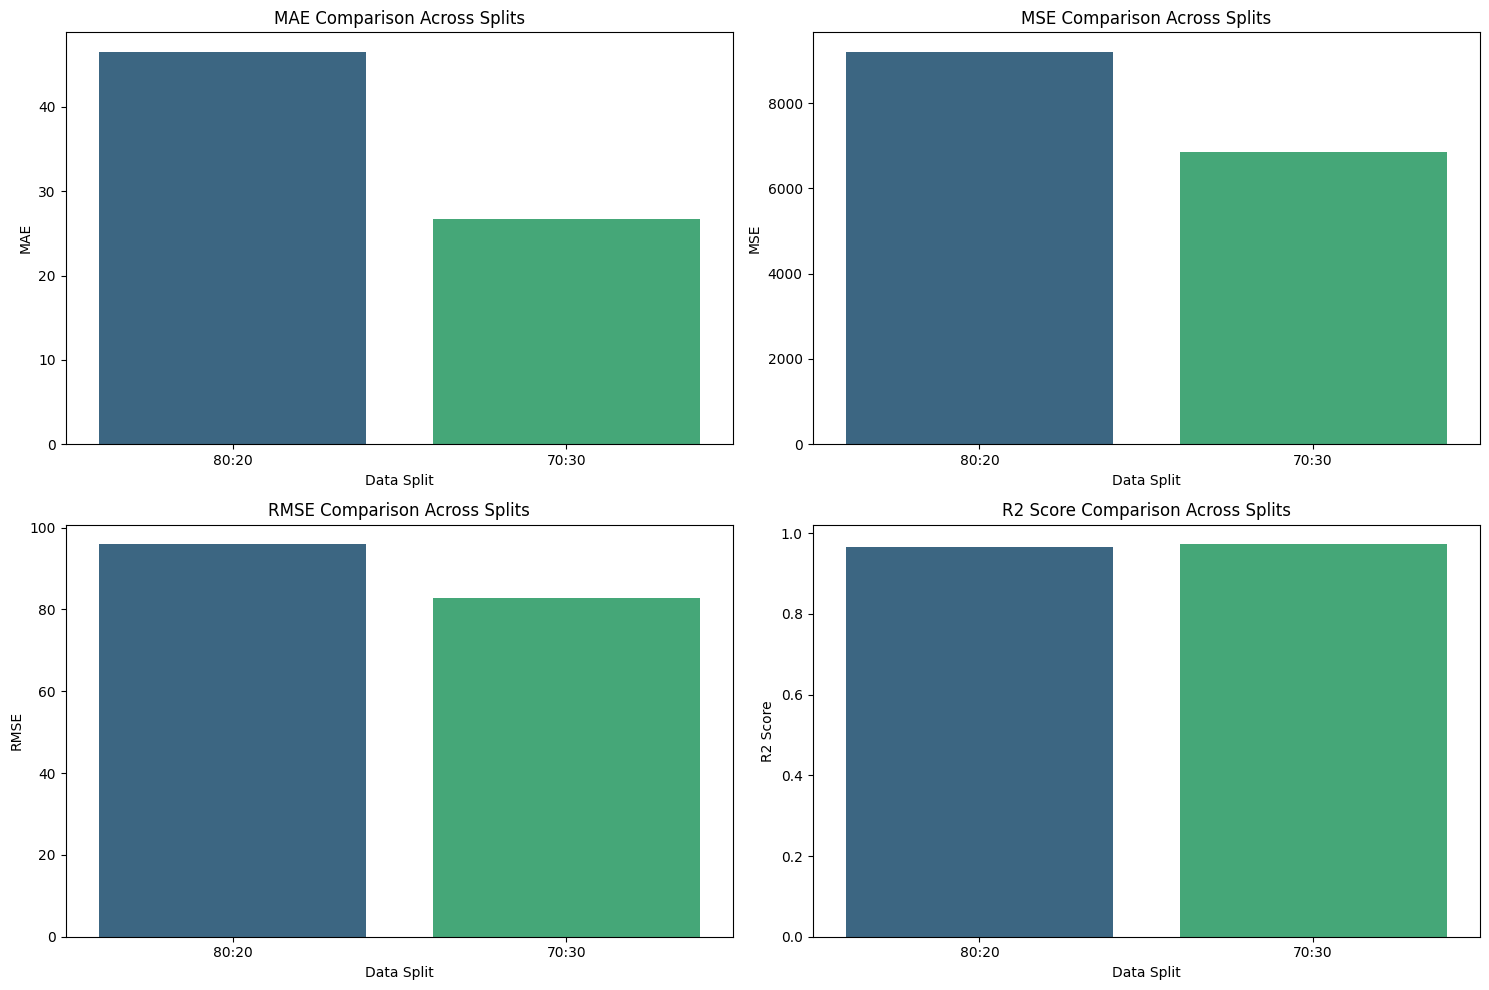

In [ ]:
metrics_to_plot = ['MAE', 'MSE', 'RMSE', 'R2 Score']

plt.figure(figsize=(15, 10))

for i, metric in enumerate(metrics_to_plot):
    plt.subplot(2, 2, i + 1)  # Create a 2x2 grid of subplots
    sns.barplot(x='Split', y=metric, data=comparison_df, palette='viridis')
    plt.title(f'{metric} Comparison Across Splits')
    plt.ylabel(metric)
    plt.xlabel('Data Split')

plt.tight_layout()
plt.show()


### **10. Comparison of Evaluation Metrics Across Splits**

Let's compare the Mean Absolute Error (MAE), Mean Squared Error (MSE), and Root Mean Squared Error (RMSE) across the 80:20 and 70:30 splits to see which split performed better.

In [ ]:
comparison_df = pd.DataFrame({
    'Split': ['80:20', '70:30'],
    'MAE': [metrics_80_20['MAE'], metrics_70_30['MAE']],
    'MSE': [metrics_80_20['MSE'], metrics_70_30['MSE']],
    'RMSE': [metrics_80_20['RMSE'], metrics_70_30['RMSE']],
    'R2 Score': [metrics_80_20['R2 Score'], metrics_70_30['R2 Score']]
})

print("Comparison of Evaluation Metrics:")
display(comparison_df)


Comparison of Evaluation Metrics:


,Split,MAE,MSE,RMSE,R2 Score
0,80:20,46.511932,9197.323664,95.902678,0.966263
1,70:30,26.709594,6856.124191,82.801716,0.972206


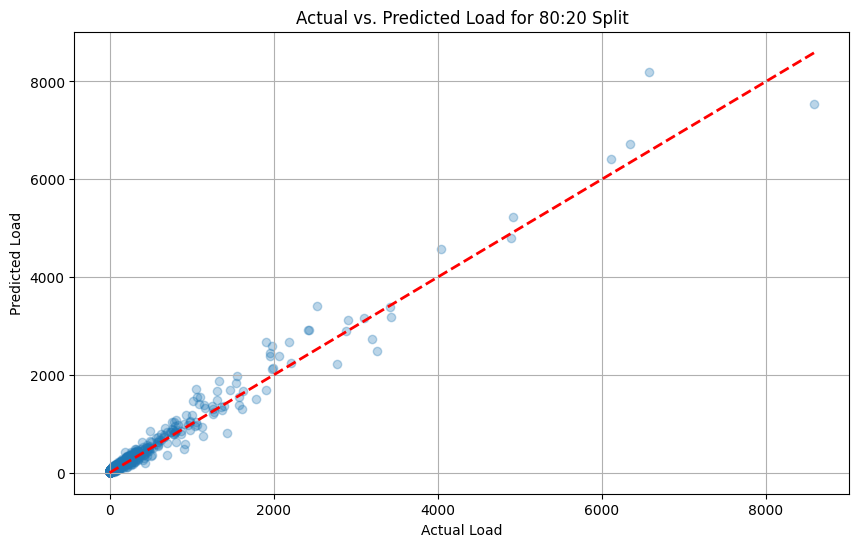

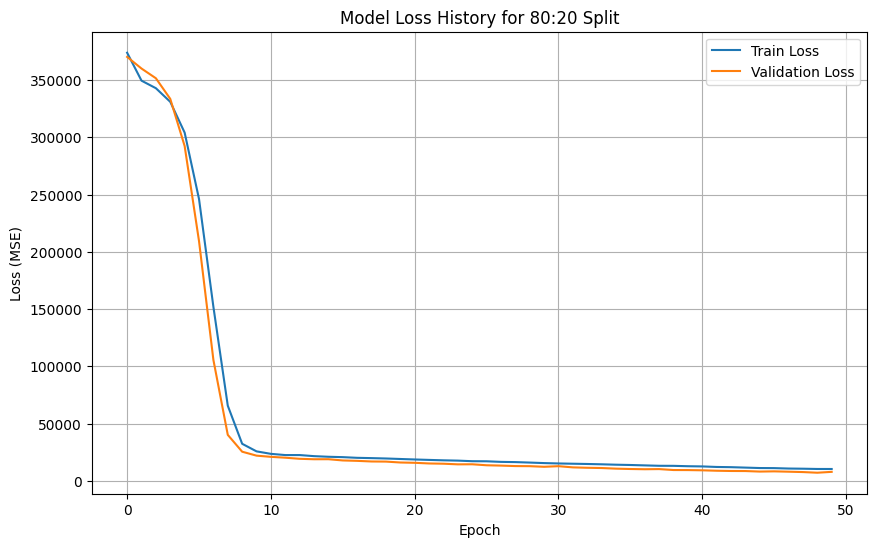

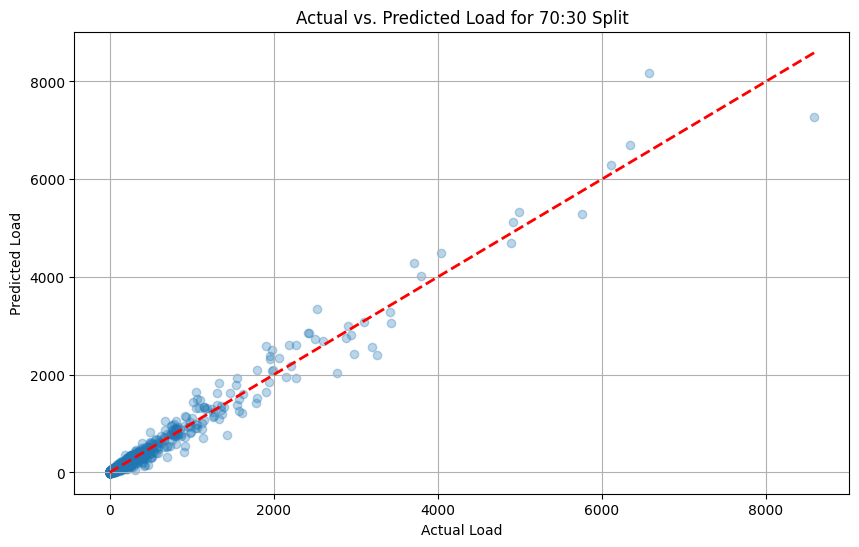

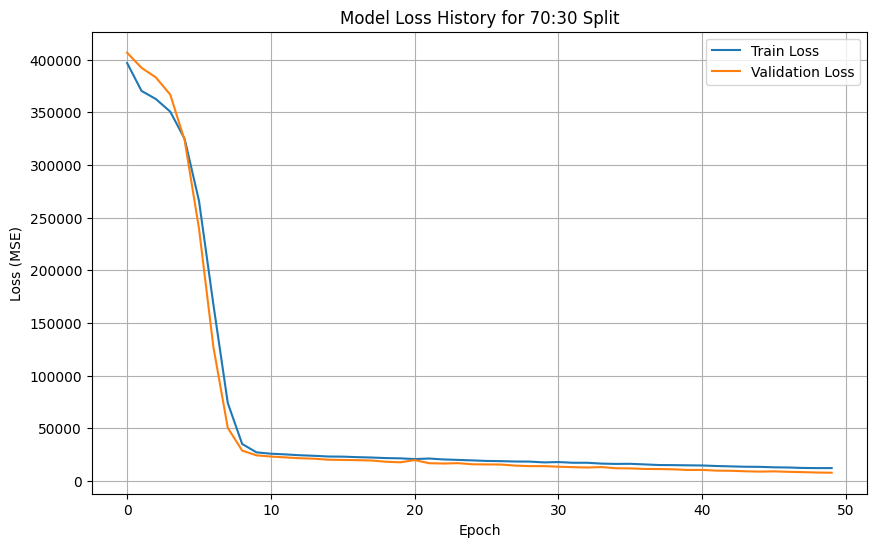

In [ ]:
def plot_predictions(y_test, y_pred, split_name):
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_pred, alpha=0.3)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Diagonal line
    plt.xlabel('Actual Load')
    plt.ylabel('Predicted Load')
    plt.title(f'Actual vs. Predicted Load for {split_name} Split')
    plt.grid(True)
    plt.show()

def plot_loss_history(history, split_name):
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'Model Loss History for {split_name} Split')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.grid(True)
    plt.show()

# Plot for 80:20 Split
plot_predictions(y_test_80_20, y_pred_80_20, "80:20")
plot_loss_history(history_80_20, "80:20")

# Plot for 70:30 Split
plot_predictions(y_test_70_30, y_pred_70_30, "70:30")
plot_loss_history(history_70_30, "70:30")


In [ ]:
print("Dataset Information:")
df.info()
print("\nDescriptive statistics of numerical columns:")
display(df.describe())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8335 entries, 0 to 8334
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Circle          8335 non-null   object 
 1   Division        8335 non-null   object 
 2   SubDivision     8335 non-null   object 
 3   Section         8335 non-null   object 
 4   Area            8335 non-null   object 
 5   CatCode         8335 non-null   int64  
 6   CatDesc         8335 non-null   object 
 7   TotServices     8335 non-null   int64  
 8   BilledServices  8335 non-null   int64  
 9   Units           8335 non-null   int64  
 10  Load            8335 non-null   float64
dtypes: float64(1), int64(4), object(6)
memory usage: 716.4+ KB

Descriptive statistics of numerical columns:


,CatCode,TotServices,BilledServices,Units,Load
count,8335.0,8335.000000,8335.000000,8335.000000,8335.000000
mean,2.0,71.645591,62.669706,9143.704979,161.148227
std,0.0,234.764216,202.619562,33388.240357,582.837500
min,2.0,1.000000,0.000000,0.000000,0.100000
25%,2.0,4.000000,3.000000,131.000000,6.000000
50%,2.0,14.000000,12.000000,1056.000000,25.500000
75%,2.0,45.000000,39.000000,5491.000000,82.861500
max,2.0,5013.000000,3954.000000,844628.000000,14618.871000
